In [1]:
# %% Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# %% Dataset Preparation
# Define single-channel data transformations
data_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert to grayscale
    transforms.Resize((128, 128)),  # Resize images
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize for a single channel
])

# Load the dataset
data_dir = 'cropped_faces_dataset'  # Update with your dataset directory
full_dataset = datasets.ImageFolder(data_dir, transform=data_transform)

# Split dataset into train, validation, and test sets
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Create DataLoaders
batch_size = 16
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
    'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
    'test': DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
}
dataset_sizes = {'train': train_size, 'val': val_size, 'test': test_size}
class_names = full_dataset.classes
num_classes = len(class_names)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Number of classes: {num_classes}")

Number of classes: 699


In [2]:
# %% Hard Attention Mechanism
class HardAttention(nn.Module):
    def __init__(self, in_channels):
        super(HardAttention, self).__init__()
        self.query = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))  # Learnable scaling parameter

    def forward(self, x):
        batch_size, channels, height, width = x.size()

        # Compute query, key, and value
        query = self.query(x).view(batch_size, -1, height * width)  # [B, C/8, H*W]
        key = self.key(x).view(batch_size, -1, height * width)  # [B, C/8, H*W]
        value = self.value(x).view(batch_size, -1, height * width)  # [B, C, H*W]

        # Compute attention map
        attention = torch.bmm(query.permute(0, 2, 1), key)  # [B, H*W, H*W]
        attention = F.softmax(attention, dim=-1)  # Normalize across spatial positions

        # Hard attention: Zero out less important regions
        threshold = torch.mean(attention, dim=1, keepdim=True)
        hard_attention = torch.where(attention > threshold, attention, torch.zeros_like(attention))

        # Compute self-attention output
        out = torch.bmm(value, hard_attention)  # [B, C, H*W]
        out = out.view(batch_size, channels, height, width)  # Reshape back to feature map dimensions

        # Scale and combine with input
        out = self.gamma * out + x  # Apply learnable scaling and residual connection
        return out



In [3]:
# %% Define Parent Model
class SingleChannelParentModel(nn.Module):
    def __init__(self, num_classes):
        super(SingleChannelParentModel, self).__init__()
        self.backbone = models.resnet50(pretrained=True)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)  # Single-channel input
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

        # Add hard attention
        self.hard_attention = HardAttention(in_channels=2048)

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        # Apply hard attention
        attention_map = self.hard_attention(x)

        x = self.backbone.avgpool(attention_map)  # Apply pooling on attended features
        x = torch.flatten(x, 1)
        output = self.backbone.fc(x)
        return output, attention_map




In [4]:
# %% Training Function
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25):
    best_model_wts = model.state_dict()
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs, _ = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    _, preds = torch.max(outputs, 1)
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()

    model.load_state_dict(best_model_wts)
    return model

# %% Initialize and Train the Parent Model
parent_model = SingleChannelParentModel(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(parent_model.parameters(), lr=0.001, momentum=0.9)

print("Training the parent model...")
parent_model = train_model(parent_model, dataloaders, criterion, optimizer, num_epochs=25)

# Save the trained model
torch.save(parent_model.state_dict(), "parent_hard_attention_cropped.pth")
print("Parent model trained and saved.")

C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training the parent model...
Epoch 1/25
----------
train Loss: 5.8484 Acc: 0.0867
val Loss: 4.7309 Acc: 0.2224
Epoch 2/25
----------
train Loss: 4.1503 Acc: 0.3433
val Loss: 3.4731 Acc: 0.4287
Epoch 3/25
----------
train Loss: 2.9751 Acc: 0.5505
val Loss: 2.5656 Acc: 0.6104
Epoch 4/25
----------
train Loss: 2.0898 Acc: 0.7067
val Loss: 1.8370 Acc: 0.7199
Epoch 5/25
----------
train Loss: 1.4157 Acc: 0.8094
val Loss: 1.3105 Acc: 0.7988
Epoch 6/25
----------
train Loss: 0.8793 Acc: 0.8842
val Loss: 0.8859 Acc: 0.8565
Epoch 7/25
----------
train Loss: 0.4663 Acc: 0.9402
val Loss: 0.5867 Acc: 0.8990
Epoch 8/25
----------
train Loss: 0.2190 Acc: 0.9751
val Loss: 0.4203 Acc: 0.9211
Epoch 9/25
----------
train Loss: 0.0981 Acc: 0.9895
val Loss: 0.3033 Acc: 0.9363
Epoch 10/25
----------
train Loss: 0.0474 Acc: 0.9975
val Loss: 0.2655 Acc: 0.9431
Epoch 11/25
----------
train Loss: 0.0232 Acc: 0.9996
val Loss: 0.2524 Acc: 0.9440
Epoch 12/25
----------
train Loss: 0.0158 Acc: 0.9995
val Loss: 0.2

In [5]:


# %% Test Function
def test_model(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs, _ = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%")
    return avg_loss, accuracy

# %% Evaluate the Parent Model on Test Data
print("Evaluating the parent model on the test set...")
test_loss, test_accuracy = test_model(parent_model, dataloaders['test'], criterion)

Evaluating the parent model on the test set...
Test Loss: 0.2283, Test Accuracy: 96.18%


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import torch.nn.functional as F

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the processed dataset with 3 contrast channels
data_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalizing 3 channels
])

data_dir = 'processed_cropped_faces_dataset'
full_dataset = datasets.ImageFolder(data_dir, transform=data_transform)

# Split the dataset into train, validation, and test sets
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size, test_size])

batch_size = 16
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
    'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
    'test': DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
}
dataset_sizes = {'train': train_size, 'val': val_size, 'test': test_size}
class_names = full_dataset.classes
num_classes = len(class_names)

num_classes



699

In [7]:
# Define the Child Model
class ChildModel(nn.Module):
    def __init__(self, num_classes):
        super(ChildModel, self).__init__()
        self.backbone = models.resnet50(pretrained=True)
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.backbone.fc.in_features, num_classes)
        )

    def forward(self, x, return_features=False):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        if return_features:
            return x

        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.backbone.fc(x)
        return x




In [8]:

# Initialize the Child Model
child_model = ChildModel(num_classes=num_classes).to(device)

# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(child_model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

In [9]:
# Define a helper function to convert a batch of 3-channel images to grayscale
def convert_to_grayscale(inputs):
    # Combine the channels by averaging
    grayscale_inputs = inputs.mean(dim=1, keepdim=True)  # Reduce to single-channel
    return grayscale_inputs

# Updated Training Function with Early Stopping
def train_child_with_parent(parent_model, child_model, dataloaders, criterion, child_optimizer, num_epochs=25, patience=5):
    best_acc = 0.0
    best_model_wts = child_model.state_dict()
    epochs_no_improve = 0  # Counter for early stopping

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                parent_model.eval()  # Freeze the parent model
                child_model.train()  # Train the child model
            else:
                child_model.eval()  # Validation mode

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                # Convert inputs to grayscale for the parent model
                grayscale_inputs = convert_to_grayscale(inputs)

                # Zero the gradients
                if phase == 'train':
                    child_optimizer.zero_grad()

                # Forward pass through the parent model to get attention maps
                with torch.no_grad():
                    _, attention_map = parent_model(grayscale_inputs)

                # Forward pass through the child model to get features
                with torch.set_grad_enabled(phase == 'train'):
                    child_features = child_model(inputs, return_features=True)

                    # Resize attention map to match child features
                    attention_map_resized = F.interpolate(
                        attention_map, size=child_features.shape[2:], mode='bilinear', align_corners=False
                    )

                    # Compute loss
                    classification_outputs = child_model(inputs)  # Get final logits
                    classification_loss = criterion(classification_outputs, labels)
                    attention_penalty = torch.mean((attention_map_resized - child_features) ** 2)  # Regularize based on parent's attention
                    total_loss = classification_loss + 0.1 * attention_penalty

                    if phase == 'train':
                        # Backward pass
                        total_loss.backward()
                        child_optimizer.step()

                _, preds = torch.max(classification_outputs, 1)
                running_loss += total_loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Save the best model based on validation accuracy
            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = child_model.state_dict()
                    epochs_no_improve = 0  # Reset the counter if improvement occurs
                    print("Model improved and saved.")
                else:
                    epochs_no_improve += 1

        # Check early stopping criteria
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            child_model.load_state_dict(best_model_wts)
            break

    # Load best model weights
    child_model.load_state_dict(best_model_wts)

    # Save the final child model
    torch.save(child_model.state_dict(), "child_hard_attention_cropped.pth")
    print("Child model training complete and best model saved.")


In [10]:
# Train the Child Model
parent_model_path = "parent_hard_attention_cropped.pth"
parent_model = SingleChannelParentModel(num_classes=num_classes).to(device)
parent_model.load_state_dict(torch.load(parent_model_path, map_location=device))
parent_model.eval()

train_child_with_parent(parent_model, child_model, dataloaders, criterion, optimizer)

C:\Users\f34rjagu\AppData\Local\Temp\ipykernel_23580\3625684889.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  parent_model.load_state_dict(torch.load(parent_model_path

Epoch 1/25
----------
train Loss: 6.8026 Acc: 0.1017
val Loss: 5.4502 Acc: 0.2920
Model improved and saved.
Epoch 2/25
----------
train Loss: 4.9970 Acc: 0.3753
val Loss: 3.9955 Acc: 0.5560
Model improved and saved.
Epoch 3/25
----------
train Loss: 3.7057 Acc: 0.6076
val Loss: 3.0775 Acc: 0.7003
Model improved and saved.
Epoch 4/25
----------
train Loss: 2.8298 Acc: 0.7621
val Loss: 2.4040 Acc: 0.7937
Model improved and saved.
Epoch 5/25
----------
train Loss: 2.2511 Acc: 0.8505
val Loss: 2.0159 Acc: 0.8548
Model improved and saved.
Epoch 6/25
----------
train Loss: 1.8718 Acc: 0.9036
val Loss: 1.7665 Acc: 0.8922
Model improved and saved.
Epoch 7/25
----------
train Loss: 1.6102 Acc: 0.9393
val Loss: 1.5777 Acc: 0.9194
Model improved and saved.
Epoch 8/25
----------
train Loss: 1.4428 Acc: 0.9649
val Loss: 1.4694 Acc: 0.9304
Model improved and saved.
Epoch 9/25
----------
train Loss: 1.3266 Acc: 0.9755
val Loss: 1.3711 Acc: 0.9508
Model improved and saved.
Epoch 10/25
----------
train

In [12]:

# Evaluate the Child Model
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy

child_model.load_state_dict(torch.load("child_hard_attention_cropped.pth"))
evaluate_model(child_model, dataloaders['test'])


C:\Users\f34rjagu\AppData\Local\Temp\ipykernel_23580\3148778639.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  child_model.load_state_dict(torch.load("child_hard_atten

Test Accuracy: 96.27%


96.26802374893978

C:\Users\f34rjagu\AppData\Local\Temp\ipykernel_23580\1643592781.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  child_model.load_state_dict(torch.load(model_path))


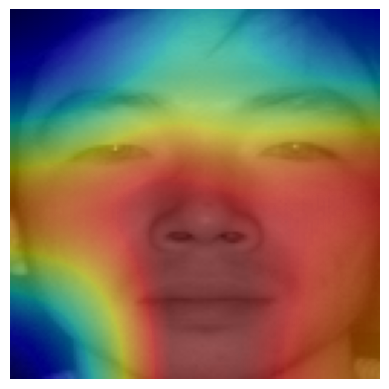

In [24]:
# Import necessary libraries for Grad-CAM
import numpy as np
import matplotlib.pyplot as plt

# Define the Grad-CAM class
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None

        # Hook to capture gradients and features
        self.target_layer.register_forward_hook(self.save_features)
        self.target_layer.register_backward_hook(self.save_gradients)

    def save_features(self, module, input, output):
        self.features = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.to(device)

        # Forward pass
        outputs = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(outputs, dim=1).item()

        # Backward pass for the predicted class
        self.model.zero_grad()
        target = outputs[0, class_idx]
        target.backward()

        # Pool the gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        for i in range(self.features.size(1)):
            self.features[0, i, :, :] *= pooled_gradients[i]

        # Generate heatmap
        heatmap = torch.mean(self.features, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().detach().numpy()

# Preprocess an input image for Grad-CAM
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Match the processed dataset
    ])
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0)
    return input_tensor, image

# Overlay the Grad-CAM heatmap on the original image
def overlay_heatmap(original_image, heatmap):
    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize((original_image.width, original_image.height), Image.Resampling.LANCZOS)
    heatmap = np.array(heatmap)

    plt.imshow(original_image)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)  # Overlay heatmap with transparency
    plt.axis('off')
    plt.show()

# Load the trained child model
model_path = "child_hard_attention_cropped.pth"
child_model.load_state_dict(torch.load(model_path))
child_model.eval()

# Define the target layer for Grad-CAM (last convolutional layer of the child model)
target_layer = child_model.backbone.layer4[-1]  # Adjust if necessary
grad_cam = GradCAM(child_model, target_layer)

# Function to generate Grad-CAM for a given image
def generate_gradcam(image_path):
    # Preprocess the image
    input_tensor, original_image = preprocess_image(image_path)

    # Generate Grad-CAM heatmap
    heatmap = grad_cam(input_tensor)

    # Overlay the heatmap on the original image
    overlay_heatmap(original_image, heatmap)

# Example usage: Generate Grad-CAM for a single image
image_path = "cropped_faces_dataset\\00001\\001.bmp"  # Replace with the path to your image
generate_gradcam(image_path)


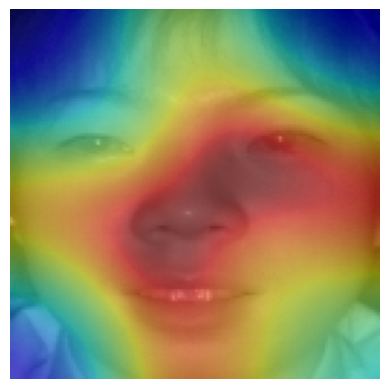

In [23]:
# Test the Grad-CAM implementation
image_path = "cropped_faces_dataset\\00182\\003.bmp"  # Replace with the path to your image
generate_gradcam(image_path)

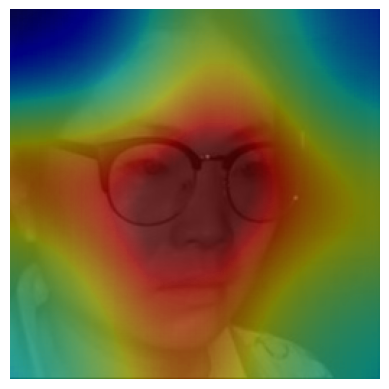

In [16]:
# Preprocess the input image
image_path = "LAMPHQ\\P0046\\NIR_P0046_1_LEFT_b.jpg"  # Path to the NIR image
generate_gradcam(image_path)

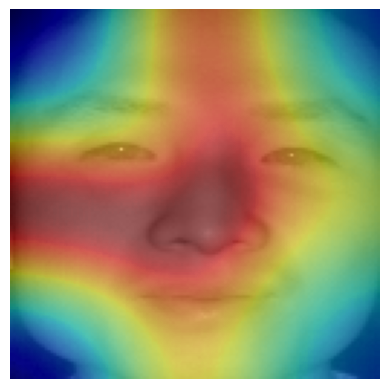

In [22]:
# Preprocess the input image
image_path = "cropped_faces_dataset\\00003\\001.bmp"  # Path to the NIR image
generate_gradcam(image_path)

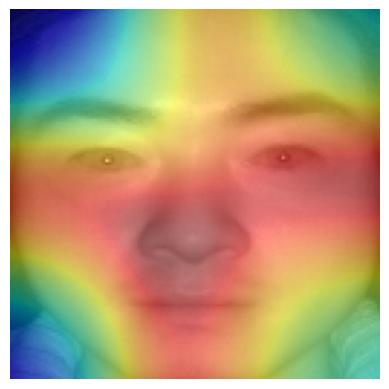

In [25]:
# Preprocess the input image 
image_path = "cropped_faces_dataset\\00046\\003.bmp"  # Path to the NIR image
generate_gradcam(image_path)